# Stock Prediction

This project introduces common techniques to manipulate time series and make predictions using an example of a stock price.

The data is a sample from the historical [US stock prices in the last 5 years] for Tesla. You can easily change this to the company of your choice. 

This project is just an example, it is not financial advice. :) 

In [3]:
import yfinance as yf

tesla = yf.Ticker("TSLA")

## Clean data 

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set()

from itertools import product

import statsmodels.api as sm
import statsmodels.tsa.api as smt
from scipy.optimize import minimize
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    median_absolute_error,
    r2_score,
)
from tqdm import tqdm_notebook


def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [36]:
df = tesla.history(period="5y")
df.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-03-28 00:00:00-04:00,18.477333,18.688667,18.340000,18.574667,101611500,0.0,0.0
2019-03-29 00:00:00-04:00,18.580000,18.677334,18.299999,18.657333,89869500,0.0,0.0
2019-04-01 00:00:00-04:00,18.841333,19.280001,18.752001,19.278667,121656000,0.0,0.0
2019-04-02 00:00:00-04:00,19.219999,19.296000,18.925333,19.058666,82183500,0.0,0.0
2019-04-03 00:00:00-04:00,19.154667,19.744667,19.144667,19.454000,118791000,0.0,0.0
2019-04-04 00:00:00-04:00,17.459333,18.080000,17.372667,17.851999,355810500,0.0,0.0
2019-04-05 00:00:00-04:00,17.990667,18.406668,17.740667,18.330667,195574500,0.0,0.0
2019-04-08 00:00:00-04:00,18.512667,18.743999,18.029333,18.213333,156156000,0.0,0.0
2019-04-09 00:00:00-04:00,18.110001,18.333332,17.974001,18.153999,88560000,0.0,0.0


In [7]:
df.shape

(3460, 7)

In [8]:
df.dtypes

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

## Exploratory data analysis (EDA)

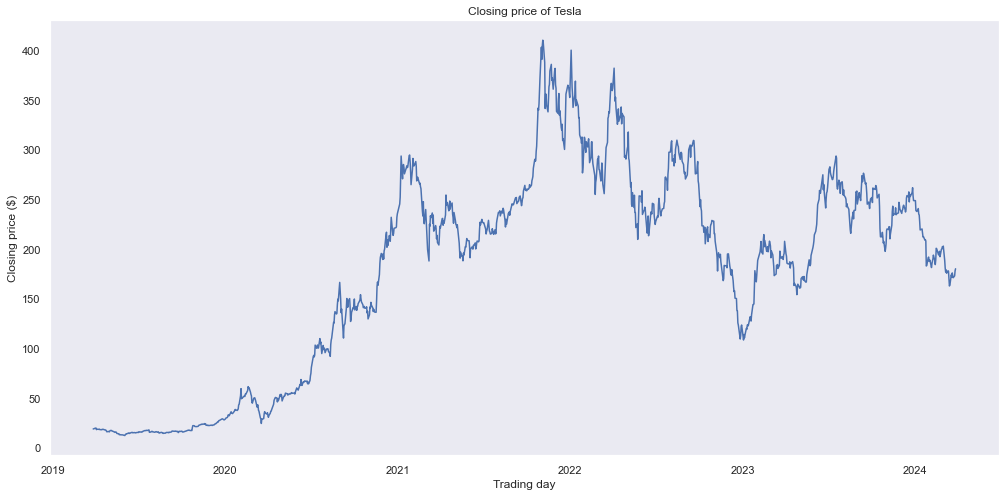

In [37]:
plt.figure(figsize=(17, 8))
plt.plot(df["Close"])
plt.title("Closing price of Tesla")
plt.ylabel("Closing price ($)")
plt.xlabel("Trading day")
plt.grid(False)
plt.show()

### Moving average

In [38]:
def plot_moving_average(series, window, plot_intervals=False, scale=1.96):

    rolling_mean = series.rolling(window=window).mean()

    plt.figure(figsize=(17, 8))
    plt.title(f"Moving average\n window size = {window}")
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

    # Plot confidence intervals for smoothed values
    if plot_intervals:
        mae = mean_absolute_error(series[window:], rolling_mean[window:])
        deviation = np.std(series[window:] - rolling_mean[window:])
        lower_bound = rolling_mean - (mae + scale * deviation)
        upper_bound = rolling_mean + (mae + scale * deviation)
        plt.plot(upper_bound, "r--", label="Upper bound / Lower bound")
        plt.plot(lower_bound, "r--")

    plt.plot(series[window:], label="Actual values")
    plt.legend(loc="best")
    plt.grid(True)

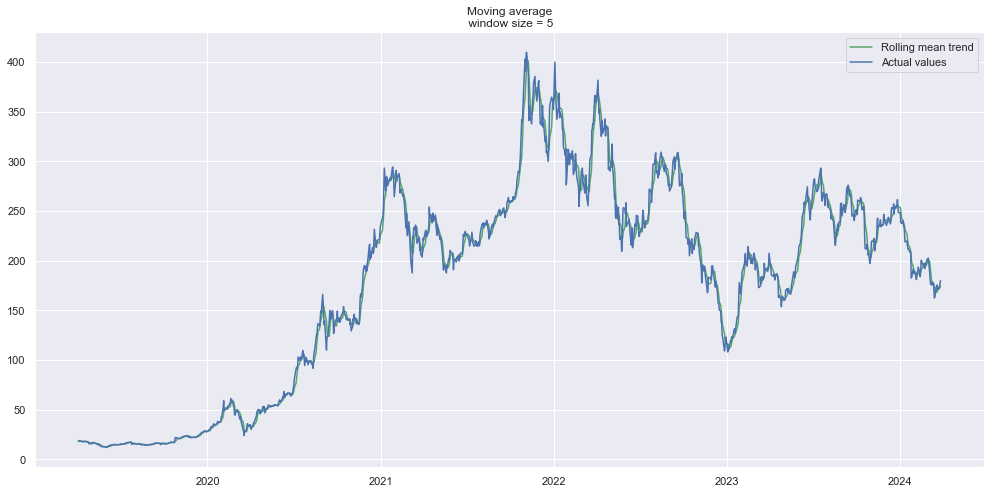

In [39]:
# Smooth by the previous 5 days (by week)
plot_moving_average(df["Close"], 5)

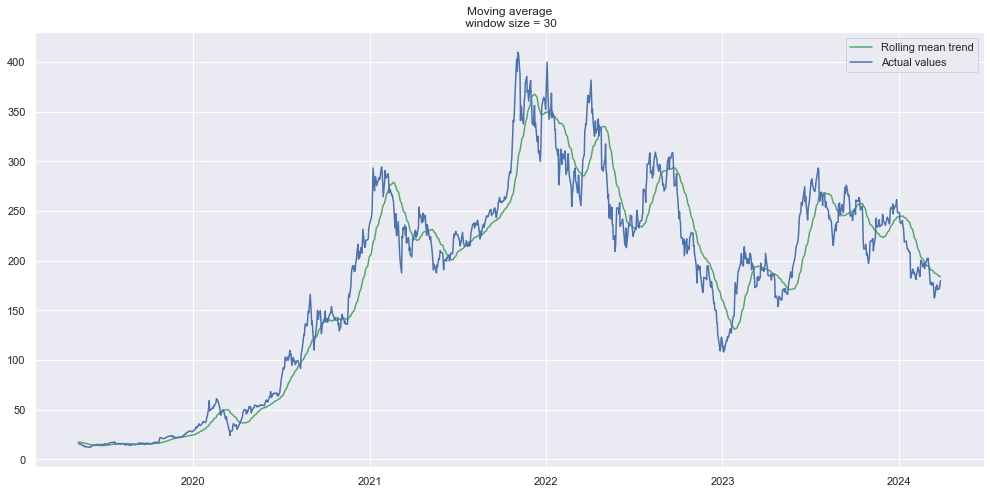

In [40]:
# Smooth by the previous month (30 days)
plot_moving_average(df["Close"], 30)

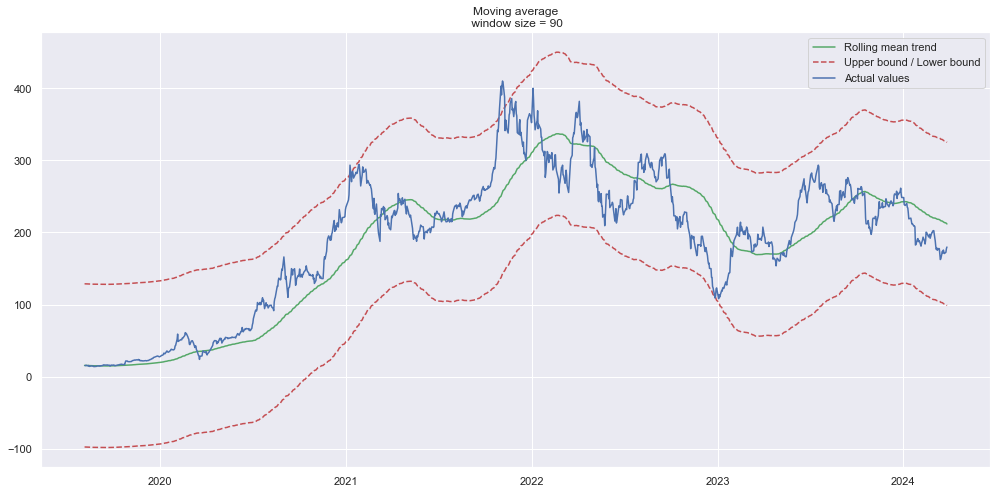

In [41]:
# Smooth by previous quarter (90 days)
plot_moving_average(df["Close"], 90, plot_intervals=True)

### Exponential smoothing

In [42]:
def exponential_smoothing(series, alpha):

    result = [series[0]]  # first value is same as series
    for n in range(1, len(series)):
        result.append(alpha * series[n] + (1 - alpha) * result[n - 1])
    return result

In [43]:
def plot_exponential_smoothing(series, alphas):

    plt.figure(figsize=(17, 8))
    for alpha in alphas:
        plt.plot(exponential_smoothing(series, alpha), label=f"Alpha {alpha}")
    plt.plot(series.values, "c", label="Actual")
    plt.legend(loc="best")
    plt.axis("tight")
    plt.title("Exponential Smoothing")
    plt.grid(True)

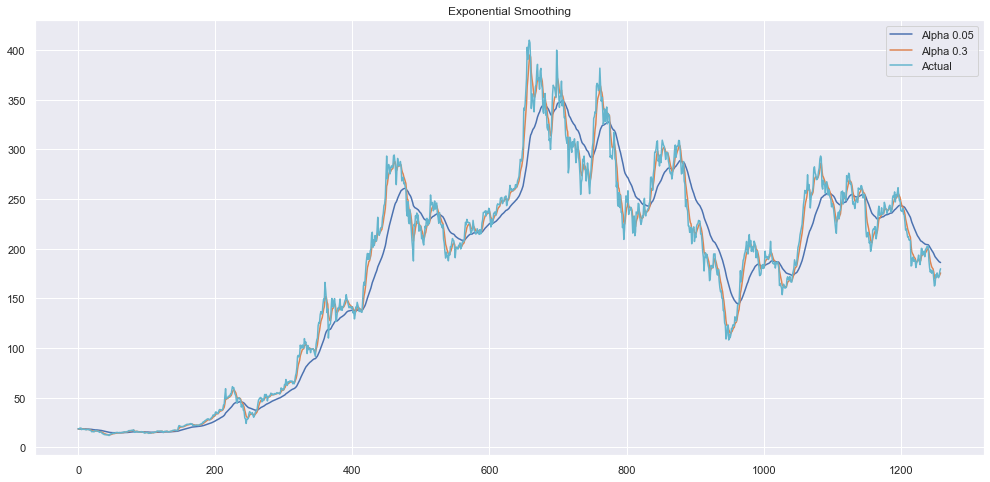

In [44]:
plot_exponential_smoothing(df["Close"], [0.05, 0.3])

### Double exponential smoothing 

In [45]:
def double_exponential_smoothing(series, alpha, beta):

    result = [series[0]]
    for n in range(1, len(series) + 1):
        if n == 1:
            level, trend = series[0], series[1] - series[0]
        if n >= len(series):  # forecasting
            value = result[-1]
        else:
            value = series[n]
        last_level, level = level, alpha * value + (1 - alpha) * (level + trend)
        trend = beta * (level - last_level) + (1 - beta) * trend
        result.append(level + trend)
    return result

In [46]:
def plot_double_exponential_smoothing(series, alphas, betas):

    plt.figure(figsize=(17, 8))
    for alpha in alphas:
        for beta in betas:
            plt.plot(
                double_exponential_smoothing(series, alpha, beta),
                label=f"Alpha {alpha}, beta {beta}",
            )
    plt.plot(series.values, label="Actual")
    plt.legend(loc="best")
    plt.axis("tight")
    plt.title("Double Exponential Smoothing")
    plt.grid(True)

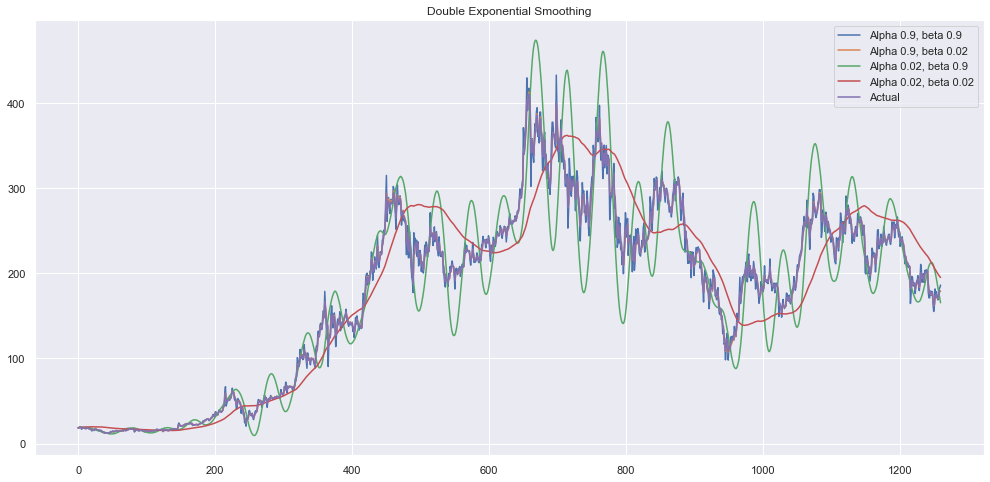

In [47]:
plot_double_exponential_smoothing(df["Close"], alphas=[0.9, 0.02], betas=[0.9, 0.02])

## Stationarity 

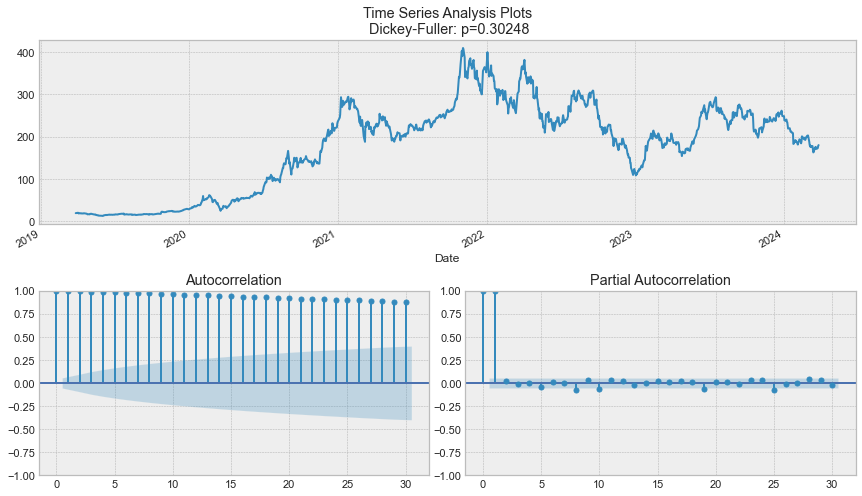

In [48]:
def tsplot(y, lags=None, figsize=(12, 7), syle="bmh"):

    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    with plt.style.context(style="bmh"):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title(f"Time Series Analysis Plots\n Dickey-Fuller: p={p_value:.5f}")
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()


tsplot(df["Close"], lags=30)

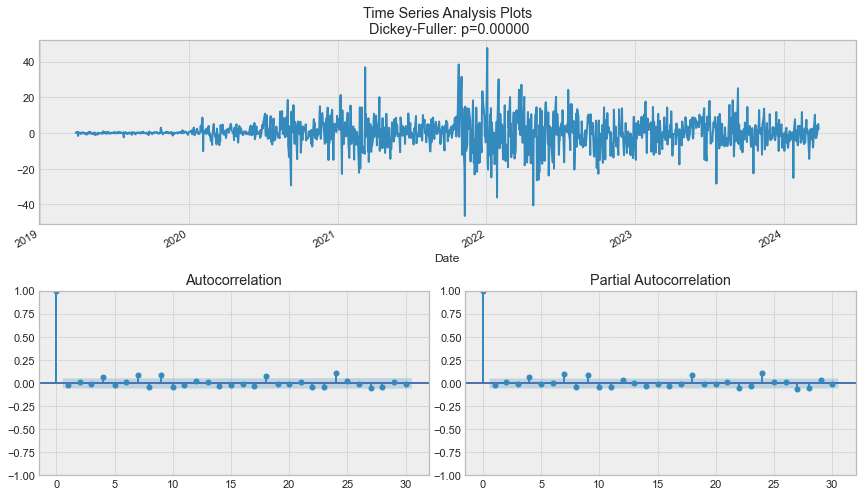

In [49]:
data_diff = df["Close"] - df["Close"].shift(1)

tsplot(data_diff[1:], lags=30)

## SARIMA

In [30]:
# Set initial values and some bounds
ps = range(0, 5)
d = 1
qs = range(0, 5)
Ps = range(0, 5)
D = 1
Qs = range(0, 5)
s = 5

# Create a list with all possible combinations of parameters
parameters = product(ps, qs, Ps, Qs)
parameters_list = list(parameters)
len(parameters_list)

625

In [33]:
def optimize_SARIMA(parameters_list, d, D, s):
    """
    Return dataframe with parameters and corresponding AIC

    parameters_list - list with (p, q, P, Q) tuples
    d - integration order
    D - seasonal integration order
    s - length of season
    """

    results = []
    best_aic = float("inf")

    for param in tqdm_notebook(parameters_list):
        try:
            model = sm.tsa.statespace.SARIMAX(
                data.CLOSE,
                order=(param[0], d, param[1]),
                seasonal_order=(param[2], D, param[3], s),
            ).fit(disp=-1)
        except:
            continue

        aic = model.aic

        # Save best model, AIC and parameters
        if aic < best_aic:
            best_model = model
            best_aic = aic
            best_param = param
        results.append([param, model.aic])

    result_table = pd.DataFrame(results)
    result_table.columns = ["parameters", "aic"]
    # Sort in ascending order, lower AIC is better
    result_table = result_table.sort_values(by="aic", ascending=True).reset_index(
        drop=True
    )

    return result_table


result_table = optimize_SARIMA(parameters_list, d, D, s)

  0%|          | 0/625 [00:00<?, ?it/s]

ValueError: Length mismatch: Expected axis has 0 elements, new values have 2 elements

In [34]:
# Set parameters that give the lowest AIC (Akaike Information Criteria)

p, q, P, Q = result_table.parameters[0]

best_model = sm.tsa.statespace.SARIMAX(
    df["Close"], order=(p, d, q), seasonal_order=(P, D, Q, s)
).fit(disp=-1)

print(best_model.summary())

NameError: name 'result_table' is not defined

In [35]:
def plot_SARIMA(series, model, n_steps):
    """
    Plot model vs predicted values

    series - dataset with time series
    model - fitted SARIMA model
    n_steps - number of steps to predict in the future
    """

    data = series.copy().rename(columns={"Close": "actual"})
    data["arima_model"] = model.fittedvalues
    # Make a shift on s+d steps, because these values were unobserved by the model due to the differentiating
    data["arima_model"][: s + d] = np.NaN

    # Forecast on n_steps forward
    forecast = model.predict(start=data.shape[0], end=data.shape[0] + n_steps)
    forecast = data.arima_model.append(forecast)
    # Calculate error
    error = mean_absolute_percentage_error(
        data["actual"][s + d :], data["arima_model"][s + d :]
    )

    plt.figure(figsize=(17, 8))
    plt.title(f"Mean Absolute Percentage Error: {error:.2f}%")
    plt.plot(forecast, color="r", label="model")
    plt.axvspan(data.index[-1], forecast.index[-1], alpha=0.5, color="lightgrey")
    plt.plot(data, label="actual")
    plt.legend()
    plt.grid(True)


# plot_SARIMA(data, best_model, 5)
print(best_model.predict(start=df["Close"].shape[0], end=df["Close"].shape[0] + 5))
print(
    mean_absolute_percentage_error(
        df["Close"][s + d :], best_model.fittedvalues[s + d :]
    )
)

NameError: name 'best_model' is not defined

In [47]:
comparison = pd.DataFrame(
    {
        "actual": [18.93, 19.23, 19.08, 19.17, 19.11, 19.12],
        "predicted": [18.96, 18.97, 18.96, 18.92, 18.94, 18.92],
    },
    index=pd.date_range(
        start="2018-06-05",
        periods=6,
    ),
)

In [48]:
comparison.head()

,actual,predicted
2018-06-05,18.93,18.96
2018-06-06,19.23,18.97
2018-06-07,19.08,18.96
2018-06-08,19.17,18.92
2018-06-09,19.11,18.94


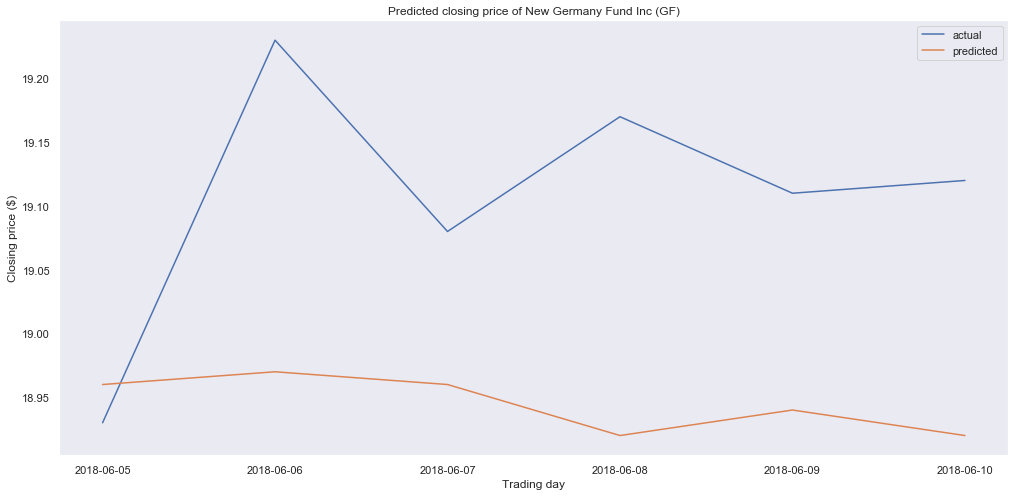

In [49]:
plt.figure(figsize=(17, 8))
plt.plot(comparison.actual)
plt.plot(comparison.predicted)
plt.title("Predicted closing price of New Germany Fund Inc (GF)")
plt.ylabel("Closing price ($)")
plt.xlabel("Trading day")
plt.legend(loc="best")
plt.grid(False)
plt.show()